In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
df.shape

(48895, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:

df['name'].fillna('Unknown', inplace=True)
df['host_name'].fillna('Unknown', inplace=True)
df['last_review'].fillna('No Review', inplace=True)
df['reviews_per_month'].fillna(0, inplace=True)

/tmp/ipykernel_1895/2807241000.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['name'].fillna('Unknown', inplace=True)
/tmp/ipykernel_1895/2807241000.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# Duplicates check cheyyi
print("Duplicates before:", df.duplicated().sum())

# Duplicates remove cheyyi
df.drop_duplicates(inplace=True)

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


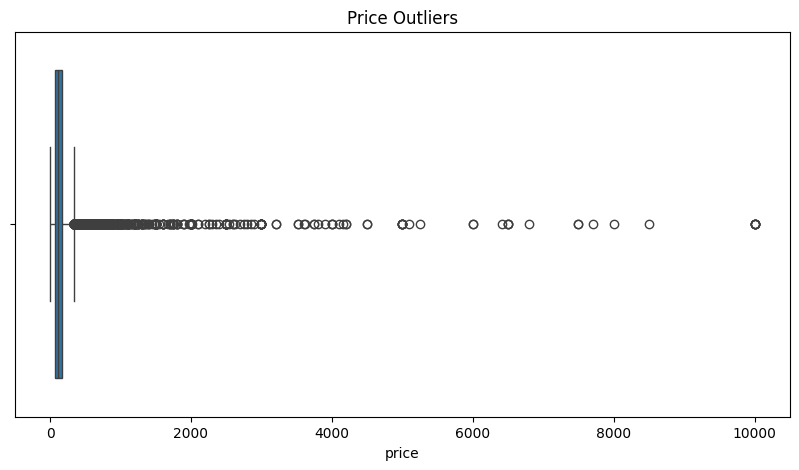

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['price'])
plt.title('Price Outliers')
plt.show()

In [ ]:
# Price outliers remove cheyyi
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df['price'] < (Q1 - 1.5 * IQR)) | (df['price'] > (Q3 + 1.5 * IQR)))]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (45923, 16)


In [ ]:
# Column names lowercase cheyyi
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Check cheyyi
print(df.columns)

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')


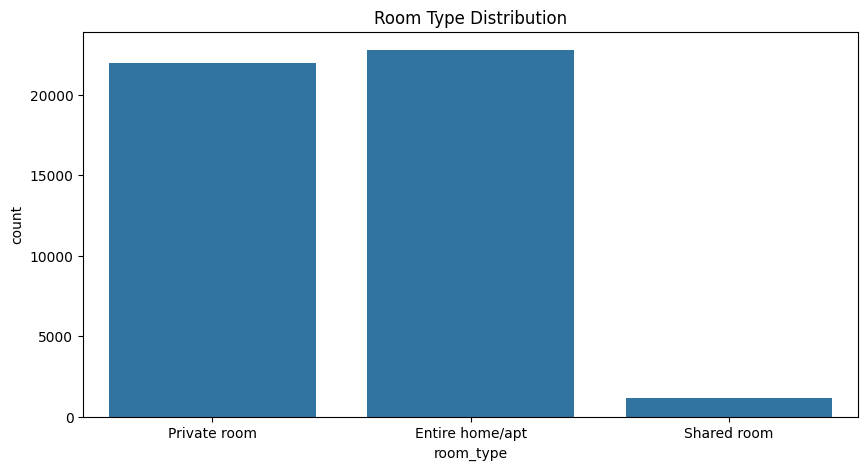

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='room_type', data=df)
plt.title('Room Type Distribution')
plt.show()

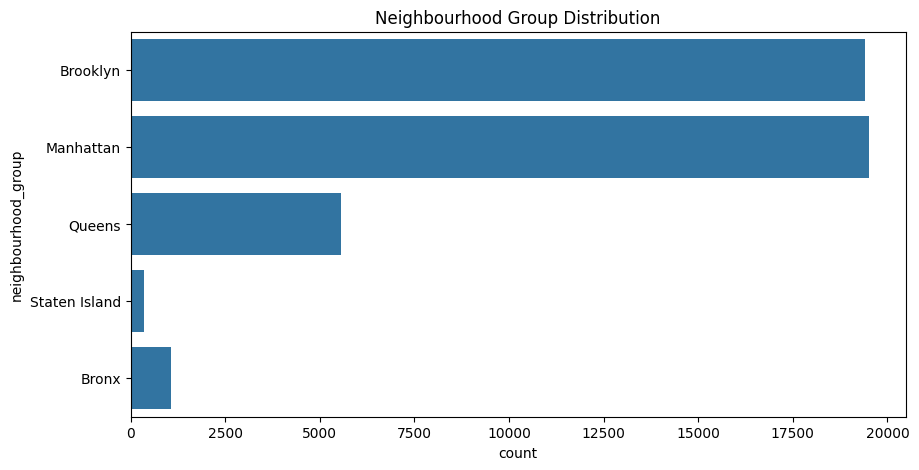

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y='neighbourhood_group', data=df)
plt.title('Neighbourhood Group Distribution')
plt.show()

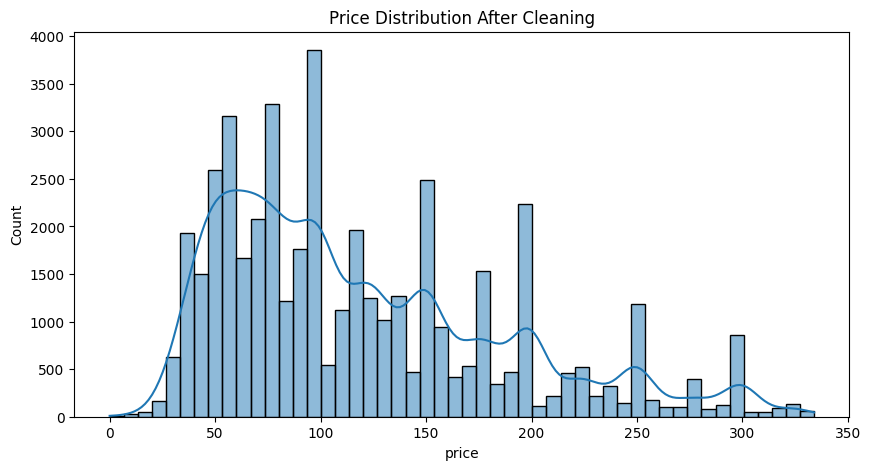

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution After Cleaning')
plt.show()

In [ ]:
df.to_csv('Cleaned_NYC_Airbnb.csv', index=False)
print("Data cleaning complete! ✅")

Data cleaning complete! ✅


In [ ]:
print("=== Data Cleaning Summary ===")
print(f"Final Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print("All cleaning steps completed successfully! ✅")

=== Data Cleaning Summary ===
Final Shape: (45923, 16)
Missing Values: 0
Duplicates: 0
All cleaning steps completed successfully! ✅


In [21]:
df2 = pd.read_csv('USvideos.csv', encoding='latin-1')
df2.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [22]:
df2.shape

(40949, 16)

In [23]:
df2.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [24]:
df2.duplicated().sum()

np.int64(48)

In [25]:
df2.drop_duplicates(inplace=True)
print("Duplicates removed! ✅")
print("New shape:", df2.shape)

Duplicates removed! ✅
New shape: (40901, 16)


In [26]:
df2.fillna('Unknown', inplace=True)
print("Missing values fixed! ✅")
df2.isnull().sum()

Missing values fixed! ✅


,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


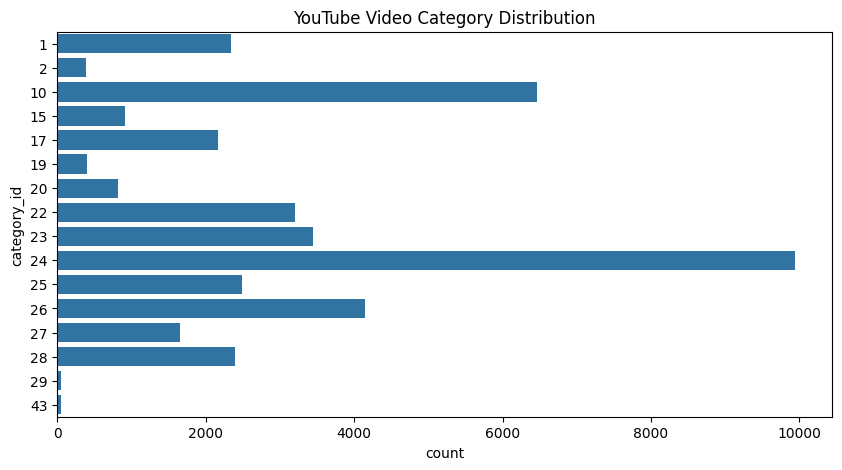

In [27]:
plt.figure(figsize=(10,5))
sns.countplot(y='category_id', data=df2)
plt.title('YouTube Video Category Distribution')
plt.show()

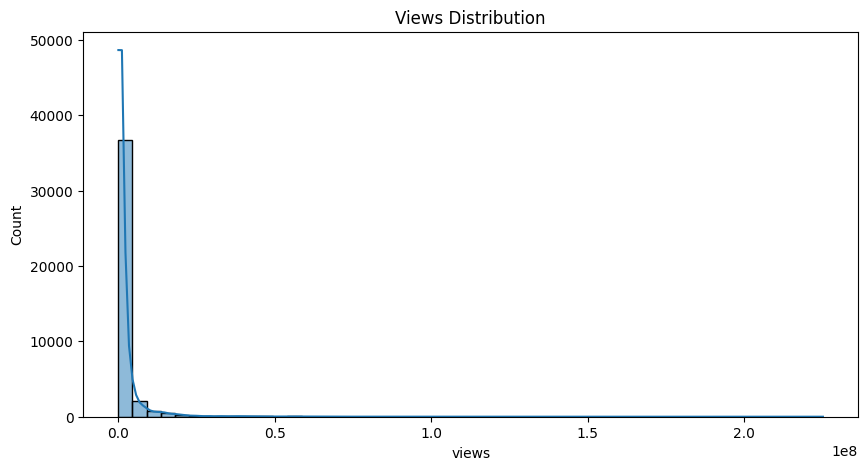

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(df2['views'], bins=50, kde=True)
plt.title('Views Distribution')
plt.show()

In [29]:
df2.to_csv('Cleaned_USvideos.csv', index=False)
print("YouTube data cleaning complete! ✅")

YouTube data cleaning complete! ✅


In [30]:
print("=== Data Cleaning Summary ===")
print("\nDataset 1 - NYC Airbnb:")
print(f"Final Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

print("\nDataset 2 - YouTube Videos:")
print(f"Final Shape: {df2.shape}")
print(f"Missing Values: {df2.isnull().sum().sum()}")
print(f"Duplicates: {df2.duplicated().sum()}")

print("\nAll cleaning steps completed successfully! ✅")

=== Data Cleaning Summary ===

Dataset 1 - NYC Airbnb:
Final Shape: (45923, 16)
Missing Values: 0
Duplicates: 0

Dataset 2 - YouTube Videos:
Final Shape: (40901, 16)
Missing Values: 0
Duplicates: 0

All cleaning steps completed successfully! ✅
